# Celdas solares de perovskita: cuando la IA fabrica mejor que el humano

756 celdas solares. 21 condiciones. Ninguna fabricada por manos humanas.

Un equipo en Nature dejó que la inteligencia artificial descubriera nuevos materiales **y** fabricara los dispositivos, en un loop cerrado sin intervención humana. ¿El resultado? Veamos qué dicen los datos.

---
📄 *Autonomous closed-loop framework for reproducible perovskite solar cells*
— Nature (2026) · DOI: [10.1038/s41586-026-10482-y](https://doi.org/10.1038/s41586-026-10482-y)

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-04-14-celulas-solares-perovskita-ia-autonoma/notebook.ipynb)

## El problema

Las celdas solares de perovskita son la gran promesa de la energía renovable: baratas, eficientes y fáciles de fabricar. Pero hay un cuello de botella: cada paso del proceso depende de la experiencia humana. Elegir el material de pasivación correcto, ajustar temperaturas, controlar espesores — todo se hace por prueba y error.

Este equipo propuso algo radical: un sistema autónomo que integra aprendizaje automático (*machine learning*) para descubrir moléculas con una plataforma automatizada que fabrica las celdas en un loop cerrado de optimización bayesiana. Sin manos humanas en el proceso.

In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
PCE_RECORD = 27.22          # PCE récord del paper (%)
PCE_CONTROL_MEAN = 22.41    # PCE medio del control manual (%)
CONDICION_MEJOR = 'S5'      # Condición con mayor PCE medio
FUENTE = 'Fuente: Nature (2026) · DOI: 10.1038/s41586-026-10482-y · Datos: Supplementary Fig. S4-S23'

COLOR_CONTROL = '#DC2626'   # Rojo — fabricación manual
COLOR_AUTO = '#2563EB'      # Azul CaM — fabricación automatizada
COLOR_MEJOR = '#059669'     # Emerald — mejor condición
COLOR_REF = '#D97706'       # Amber — referencia

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import os
import urllib.request

# Estilo CaM
style_paths = ['../../cam.mplstyle', '/tmp/cam.mplstyle']
for sp in style_paths:
    if os.path.exists(sp):
        plt.style.use(sp)
        break
else:
    url = 'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main/cam.mplstyle'
    urllib.request.urlretrieve(url, '/tmp/cam.mplstyle')
    plt.style.use('/tmp/cam.mplstyle')

# Cargar datos
df = pd.read_csv('datos/celdas_solares.csv')

# Resumen
n_conditions = df['condition'].nunique()
n_devices = len(df)
ctrl = df[df['condition'] == 'Control']
auto = df[df['condition'] != 'Control']
best = df[df['condition'] == CONDICION_MEJOR]

print(f"Datos cargados: {n_devices} dispositivos en {n_conditions} condiciones")
print(f"  Control (manual):     {len(ctrl)} dispositivos, PCE medio {ctrl['pce_pct'].mean():.2f}%")
print(f"  Automatizados:        {len(auto)} dispositivos en {auto['condition'].nunique()} condiciones")
print(f"  Mejor condición ({CONDICION_MEJOR}): PCE medio {best['pce_pct'].mean():.2f}%")
print(f"  PCE máximo en dataset: {df['pce_pct'].max():.2f}%")

Datos cargados: 756 dispositivos en 21 condiciones
  Control (manual):     36 dispositivos, PCE medio 22.41%
  Automatizados:        720 dispositivos en 20 condiciones
  Mejor condición (S5): PCE medio 25.32%
  PCE máximo en dataset: 25.96%


## Manual vs. automático

Aquí está.

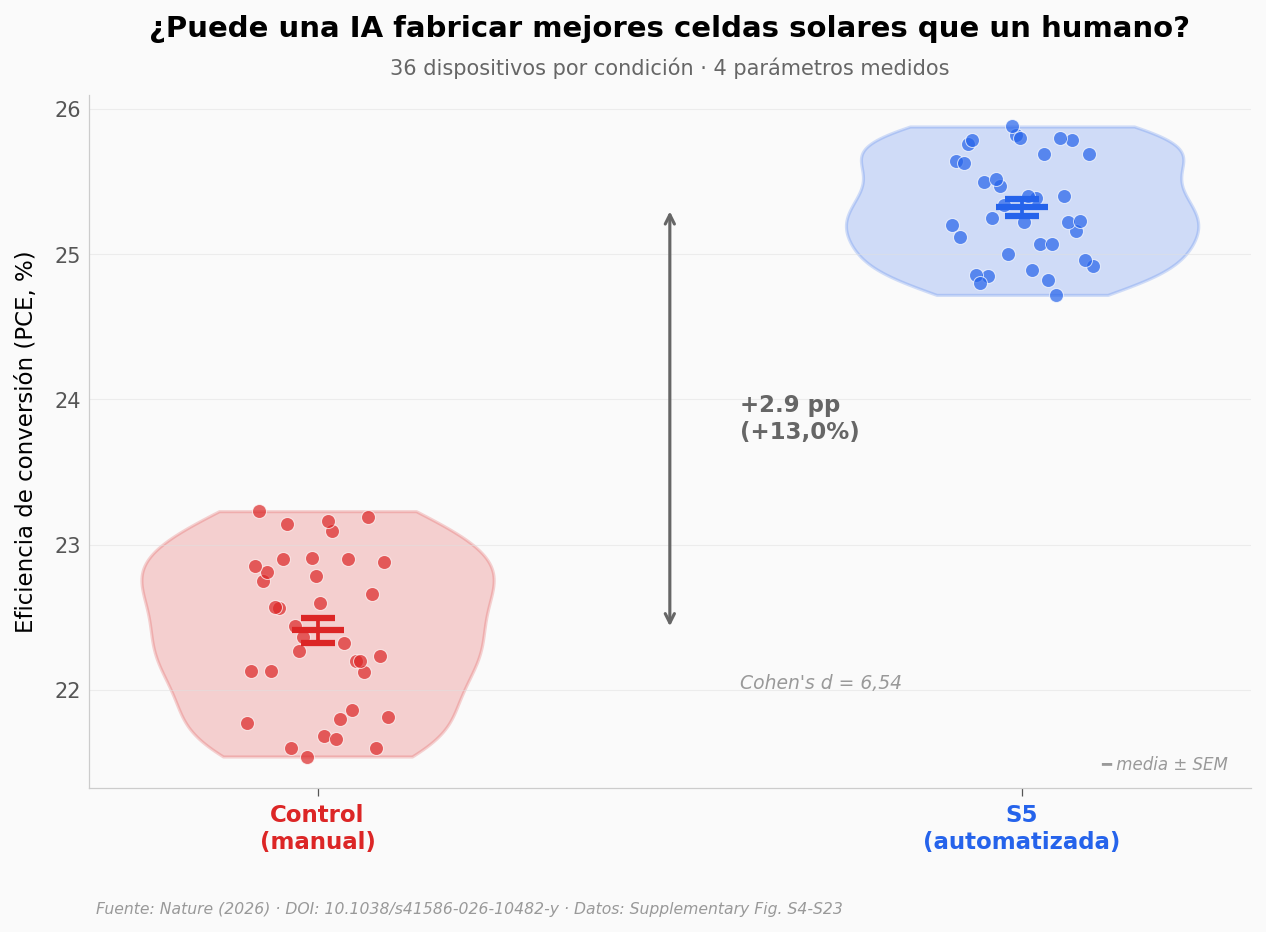

In [2]:
fig, ax = plt.subplots(figsize=(10, 6))

# Violin + strip: Control vs Best auto
positions = [0, 1.2]
groups = [
    ('Control\n(manual)', ctrl['pce_pct'].values, COLOR_CONTROL),
    (f'{CONDICION_MEJOR}\n(automatizada)', best['pce_pct'].values, COLOR_AUTO),
]

for i, (label, vals, color) in enumerate(groups):
    # Violin
    vp = ax.violinplot([vals], positions=[positions[i]], showmeans=False,
                       showextrema=False, widths=0.6)
    for body in vp['bodies']:
        body.set_facecolor(color)
        body.set_alpha(0.2)
        body.set_edgecolor(color)
        body.set_linewidth(1.5)

    # Strip (jitter)
    np.random.seed(42)
    n = len(vals)
    x_strip = np.linspace(positions[i] - 0.12, positions[i] + 0.12, n)
    np.random.shuffle(x_strip)
    ax.scatter(x_strip, vals, color=color, s=45, alpha=0.7,
               edgecolors='white', linewidths=0.5, zorder=5)

    # Mean + SEM
    mean = vals.mean()
    sem = vals.std(ddof=1) / np.sqrt(n)
    ax.errorbar(positions[i], mean, yerr=sem, fmt='_', color=color,
                markersize=25, markeredgewidth=3, capsize=8, capthick=1.5, zorder=6)

# Flecha de diferencia
y_ctrl = ctrl['pce_pct'].mean()
y_best = best['pce_pct'].mean()
ax.annotate('', xy=(0.6, y_best), xytext=(0.6, y_ctrl),
            arrowprops=dict(arrowstyle='<->', color='#666666', lw=1.5))
ax.text(0.72, (y_ctrl + y_best) / 2, f'+{y_best - y_ctrl:.1f} pp\n(+13,0%)',
        fontsize=11, fontweight='bold', color='#666666', va='center')

# Cohen's d annotation
ax.text(0.72, y_ctrl - 0.3, "Cohen's d = 6,54", fontsize=9,
        color='#999999', va='top', style='italic')

ax.set_xticks(positions)
ax.set_xticklabels(['Control\n(manual)', f'{CONDICION_MEJOR}\n(automatizada)'],
                    fontsize=11, fontweight='bold')
for tick, color in zip(ax.get_xticklabels(), [COLOR_CONTROL, COLOR_AUTO]):
    tick.set_color(color)

ax.set_ylabel('Eficiencia de conversión (PCE, %)', fontsize=11)
ax.set_title('¿Puede una IA fabricar mejores celdas solares que un humano?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, f'36 dispositivos por condición · 4 parámetros medidos',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

ax.text(0.98, 0.02, '━ media ± SEM', transform=ax.transAxes,
        fontsize=8, color='#999999', ha='right', va='bottom', style='italic')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/hero_control_vs_auto.png', dpi=200, bbox_inches='tight')
plt.show()

Las dos distribuciones no se tocan. Ni un solo dispositivo automático cae en el rango del control manual.

La mejora es de +2,9 puntos porcentuales de eficiencia — parece poco, pero en el mundo de las celdas solares es enorme. Pasamos de 22,4% a 25,3% de conversión de luz en electricidad. Un Cohen's d de 6,54 confirma lo que los ojos ven: el efecto es masivo.

¿Y qué pasa con las otras 19 condiciones que probó la IA?

## 20 rondas de optimización

La IA no se quedó con una sola receta — exploró 20 condiciones diferentes, ajustando parámetros en cada ronda.

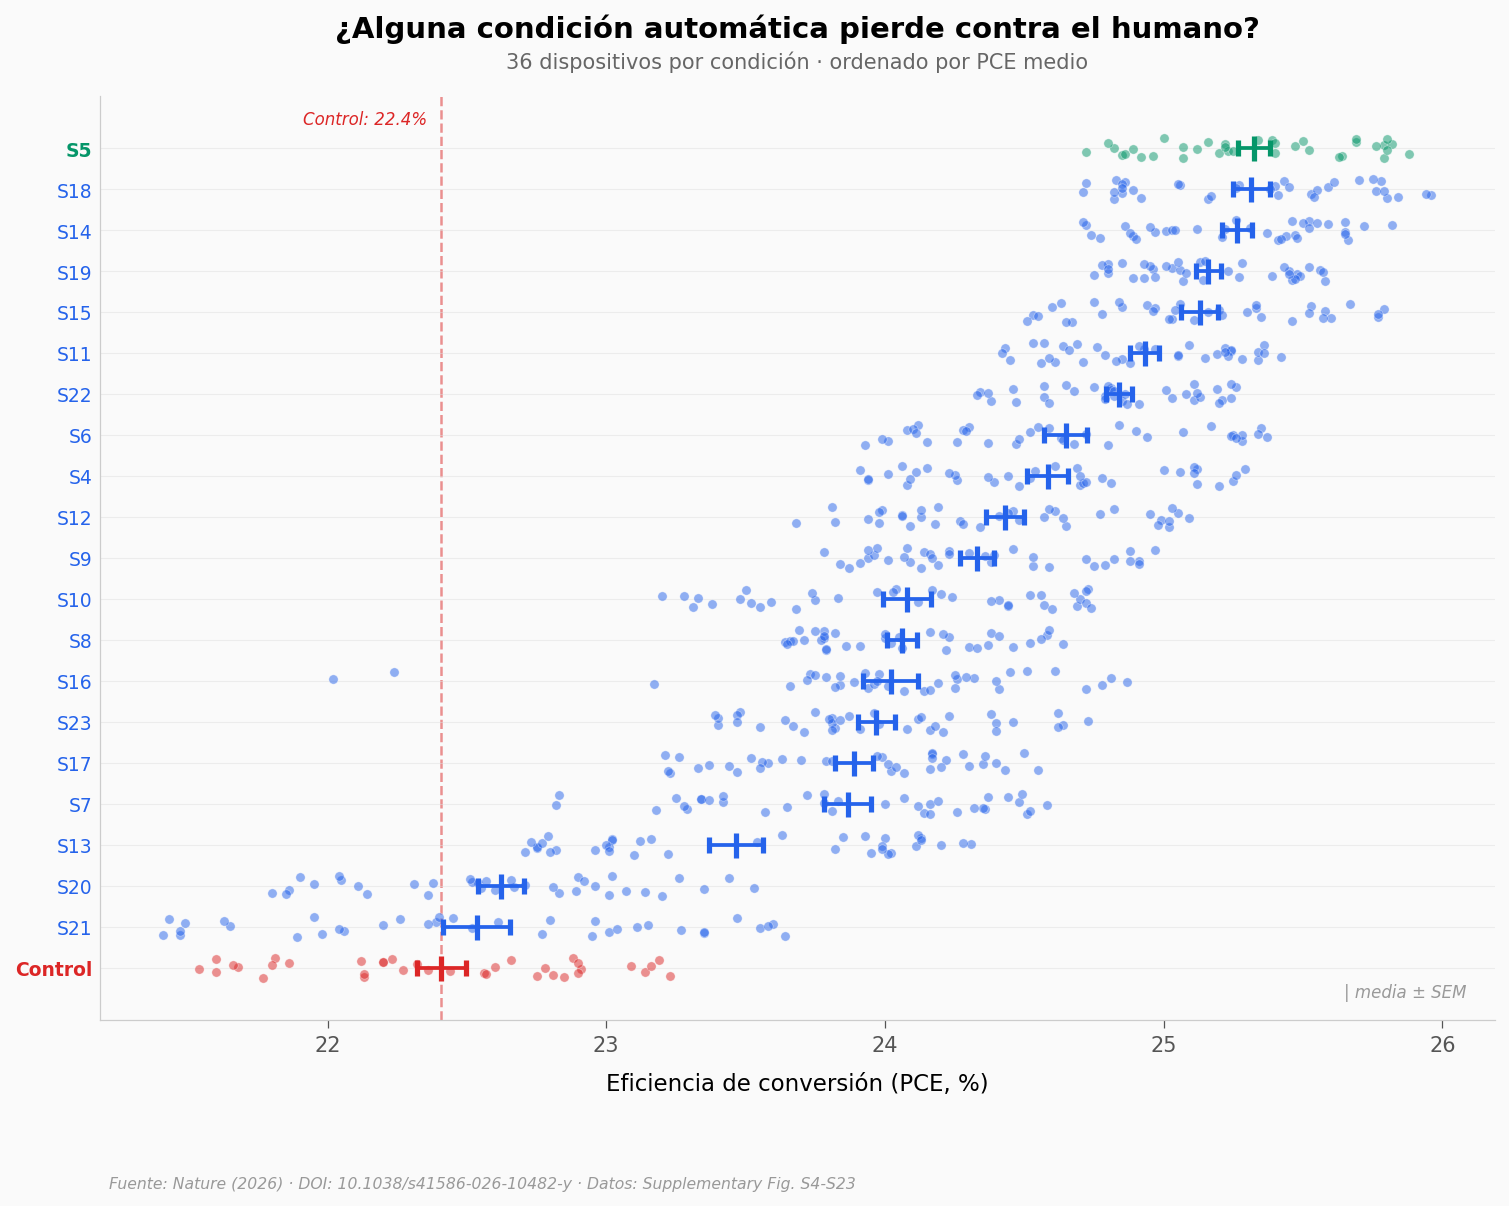

In [3]:
# Stats por condición, ordenadas por PCE medio
cond_stats = df.groupby('condition')['pce_pct'].agg(['mean', 'std', 'count']).reset_index()
cond_stats['sem'] = cond_stats['std'] / np.sqrt(cond_stats['count'])
cond_stats = cond_stats.sort_values('mean', ascending=True)

fig, ax = plt.subplots(figsize=(12, 8))

colors = []
for _, row in cond_stats.iterrows():
    if row['condition'] == 'Control':
        colors.append(COLOR_CONTROL)
    elif row['condition'] == CONDICION_MEJOR:
        colors.append(COLOR_MEJOR)
    else:
        colors.append(COLOR_AUTO)

y_pos = range(len(cond_stats))

# Strip plot por condición
np.random.seed(42)
for i, (_, row) in enumerate(cond_stats.iterrows()):
    vals = df[df['condition'] == row['condition']]['pce_pct'].values
    n = len(vals)
    y_strip = np.linspace(i - 0.25, i + 0.25, n)
    np.random.shuffle(y_strip)
    color = colors[i]
    ax.scatter(vals, y_strip, color=color, s=20, alpha=0.5,
               edgecolors='white', linewidths=0.3, zorder=4)
    # Media con error bar
    ax.errorbar(row['mean'], i, xerr=row['sem'], fmt='|', color=color,
                markersize=12, markeredgewidth=2.5, capsize=4, capthick=1.2, zorder=5)

# Línea de referencia: media del control
ax.axvline(x=ctrl['pce_pct'].mean(), color=COLOR_CONTROL, linewidth=1.2,
           linestyle='--', alpha=0.5, zorder=1)
ax.text(ctrl['pce_pct'].mean() - 0.05, len(cond_stats) - 0.5,
        f'Control: {ctrl["pce_pct"].mean():.1f}%', fontsize=8,
        color=COLOR_CONTROL, ha='right', va='bottom', style='italic')

ax.set_yticks(list(y_pos))
ax.set_yticklabels(cond_stats['condition'].values, fontsize=9)
for tick, color in zip(ax.get_yticklabels(), colors):
    tick.set_color(color)
    if color != COLOR_AUTO:
        tick.set_fontweight('bold')

ax.set_xlabel('Eficiencia de conversión (PCE, %)', fontsize=11)
ax.set_title('¿Alguna condición automática pierde contra el humano?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, '36 dispositivos por condición · ordenado por PCE medio',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

ax.text(0.98, 0.02, '| media ± SEM', transform=ax.transAxes,
        fontsize=8, color='#999999', ha='right', va='bottom', style='italic')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/todas_condiciones.png', dpi=200, bbox_inches='tight')
plt.show()

Las 20 condiciones automatizadas superan al control manual. Incluso la peor (S21, con 22,5%) está por encima de la media manual.

Pero la eficiencia (PCE) no sale de la nada. Es el producto de tres parámetros: el voltaje (VOC), el factor de llenado (FF) y la corriente (JSC). ¿Cuál mejoró más con la automatización?

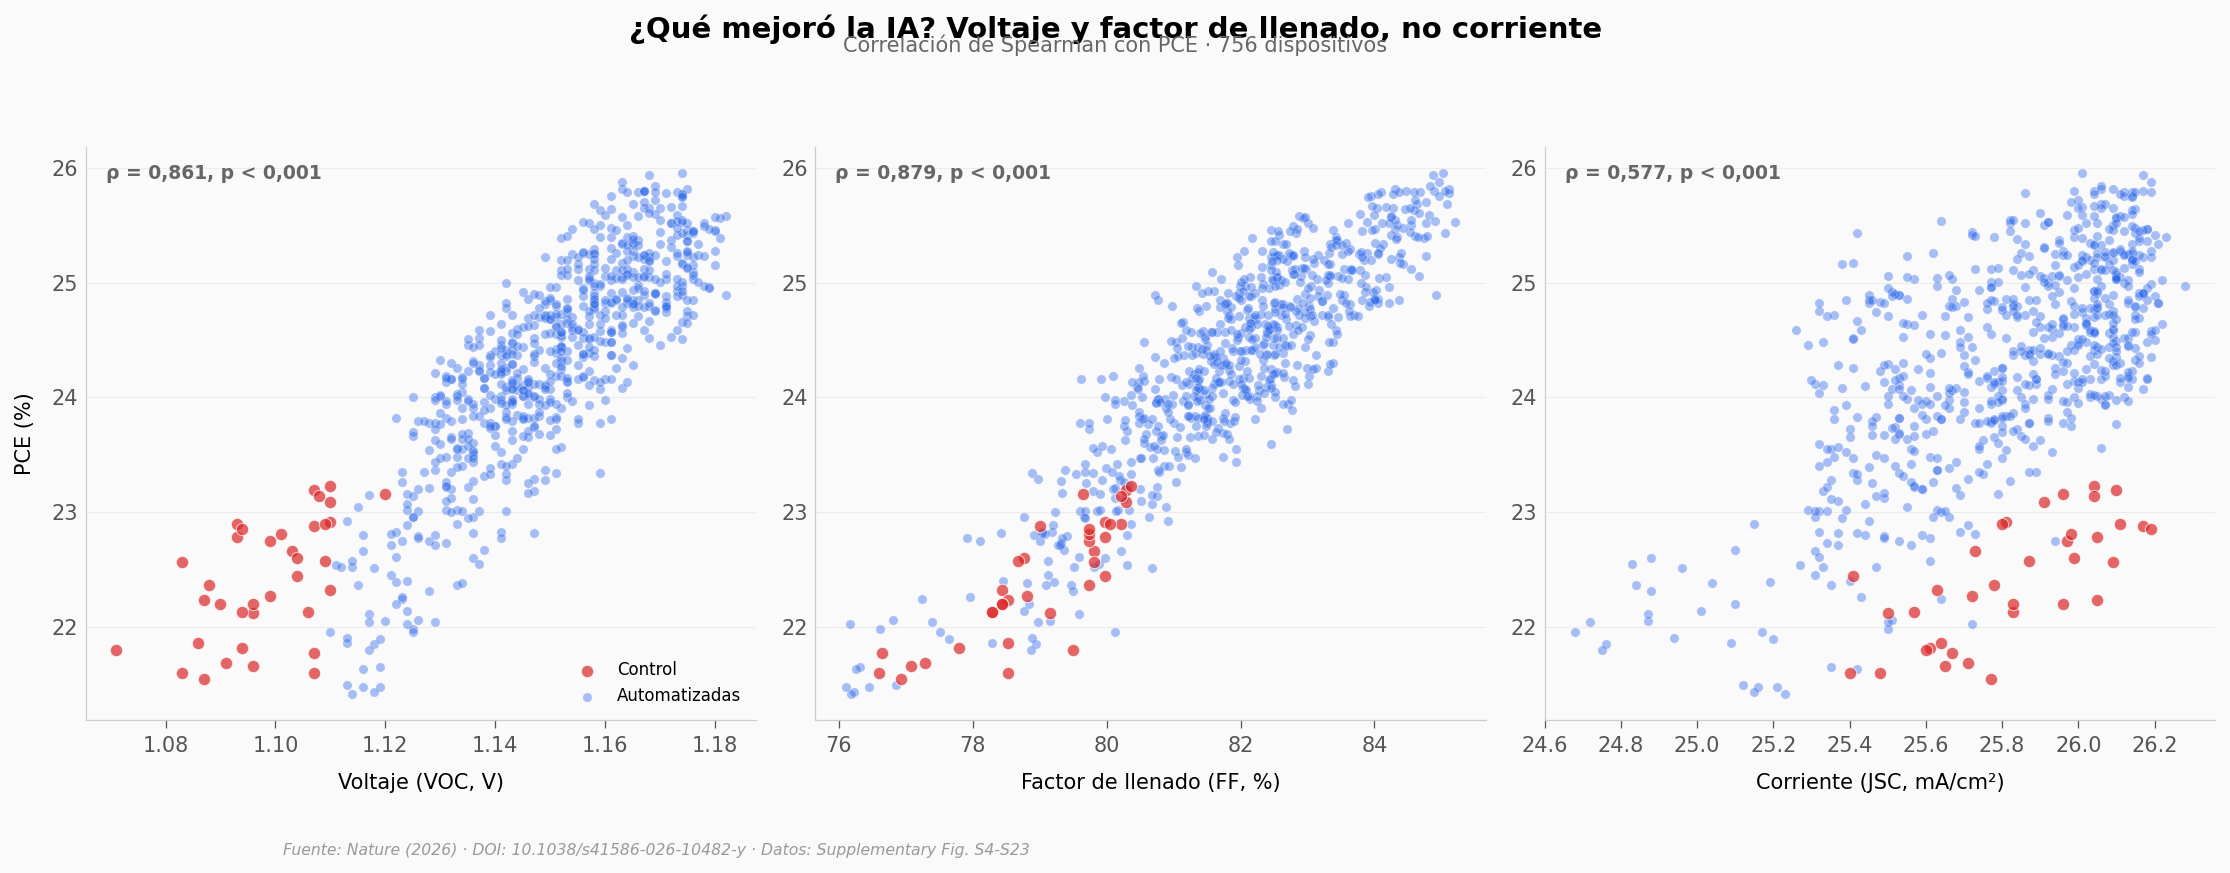

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

params = [
    ('voc_v', 'Voltaje (VOC, V)', 'ρ = 0,861'),
    ('ff_pct', 'Factor de llenado (FF, %)', 'ρ = 0,879'),
    ('jsc_ma_cm2', 'Corriente (JSC, mA/cm²)', 'ρ = 0,577'),
]

for ax, (col, ylabel, rho_label) in zip(axes, params):
    # Control
    ax.scatter(ctrl[col], ctrl['pce_pct'], color=COLOR_CONTROL, s=35, alpha=0.7,
               edgecolors='white', linewidths=0.5, zorder=5, label='Control')
    # Automatizadas
    ax.scatter(auto[col], auto['pce_pct'], color=COLOR_AUTO, s=20, alpha=0.4,
               edgecolors='white', linewidths=0.3, zorder=4, label='Automatizadas')

    ax.set_xlabel(ylabel, fontsize=10)
    ax.set_ylabel('PCE (%)' if col == 'voc_v' else '', fontsize=10)

    # Spearman rho
    ax.text(0.03, 0.97, f'{rho_label}, p < 0,001', transform=ax.transAxes, fontsize=9,
            fontweight='bold', color='#666666', va='top')

    if col == 'voc_v':
        ax.legend(fontsize=8, loc='lower right', framealpha=0.9)

fig.suptitle('¿Qué mejoró la IA? Voltaje y factor de llenado, no corriente',
             fontsize=14, fontweight='bold', y=1.07)
fig.text(0.5, 1.02, 'Correlación de Spearman con PCE · 756 dispositivos',
         fontsize=10, color='#666666', ha='center')

fig.text(0.13, -0.05, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.tight_layout()
plt.savefig('figuras/parametros_contribucion.png', dpi=200, bbox_inches='tight')
plt.show()

El factor de llenado (FF, ρ = 0,879) y el voltaje (VOC, ρ = 0,861) son los que más correlacionan con la eficiencia (Spearman, n = 756, todos p < 10⁻⁶⁸). La corriente (JSC, ρ = 0,577) contribuye menos — no es lo que explica la ganancia.

Esto tiene sentido: la molécula de pasivación (5ANI) que descubrió la IA tapa defectos en la superficie de la perovskita — y eso se nota en el voltaje y el llenado.

¿Pero qué tan fuera de lo común es la fabricación manual comparada con la automatizada?

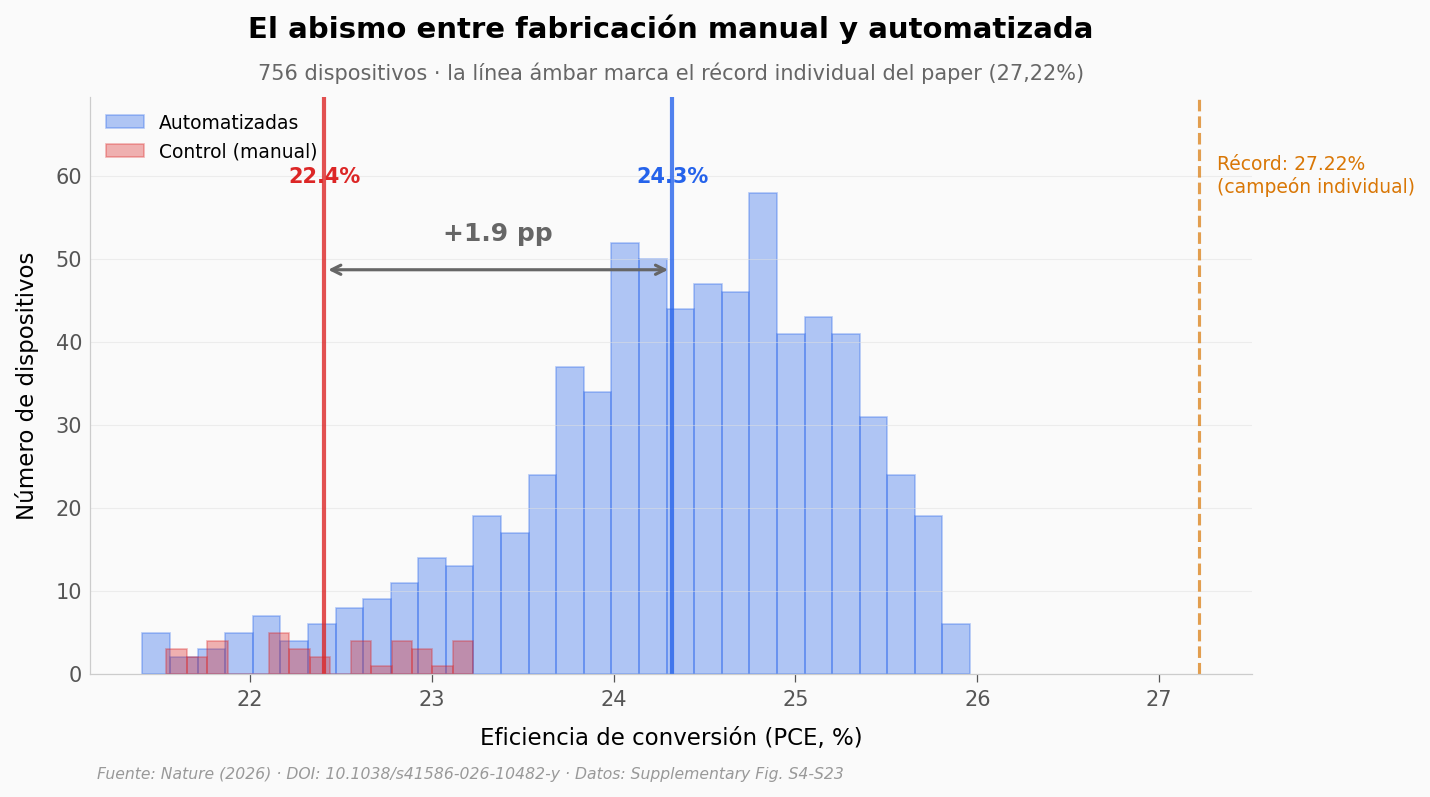

In [5]:
fig, ax = plt.subplots(figsize=(10, 5))

# Histograma de TODAS las condiciones automatizadas
n_bins, bins, patches = ax.hist(auto['pce_pct'], bins=30, color=COLOR_AUTO, alpha=0.35,
                                 edgecolor=COLOR_AUTO, linewidth=0.8, label='Automatizadas')

# Histograma del control superpuesto
ax.hist(ctrl['pce_pct'], bins=15, color=COLOR_CONTROL, alpha=0.35,
        edgecolor=COLOR_CONTROL, linewidth=0.8, label='Control (manual)')

y_max = n_bins.max() * 1.2
ax.set_ylim(0, y_max)

# Líneas de media
ctrl_mean = ctrl['pce_pct'].mean()
auto_mean = auto['pce_pct'].mean()
ax.axvline(x=ctrl_mean, color=COLOR_CONTROL, linewidth=2, linestyle='-', alpha=0.8)
ax.axvline(x=auto_mean, color=COLOR_AUTO, linewidth=2, linestyle='-', alpha=0.8)

# Flecha bidireccional
arrow_y = y_max * 0.7
ax.annotate('', xy=(auto_mean, arrow_y), xytext=(ctrl_mean, arrow_y),
            arrowprops=dict(arrowstyle='<->', color='#666666', lw=1.5))
ax.text((ctrl_mean + auto_mean) / 2, arrow_y + y_max * 0.05,
        f'+{auto_mean - ctrl_mean:.1f} pp',
        fontsize=12, fontweight='bold', color='#666666', ha='center')

# Labels
ax.text(ctrl_mean, y_max * 0.85, f'{ctrl_mean:.1f}%', fontsize=10,
        fontweight='bold', color=COLOR_CONTROL, ha='center')
ax.text(auto_mean, y_max * 0.85, f'{auto_mean:.1f}%', fontsize=10,
        fontweight='bold', color=COLOR_AUTO, ha='center')

# Récord del paper
ax.axvline(x=PCE_RECORD, color=COLOR_REF, linewidth=1.5, linestyle='--', alpha=0.7)
ax.text(PCE_RECORD + 0.1, y_max * 0.9, f'Récord: {PCE_RECORD}%\n(campeón individual)',
        fontsize=9, color=COLOR_REF, va='top')

ax.set_xlabel('Eficiencia de conversión (PCE, %)', fontsize=11)
ax.set_ylabel('Número de dispositivos', fontsize=11)
ax.legend(fontsize=9, loc='upper left', framealpha=0.9)

ax.set_title('El abismo entre fabricación manual y automatizada',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, '756 dispositivos · la línea ámbar marca el récord individual del paper (27,22%)',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/histograma_anomalia.png', dpi=200, bbox_inches='tight')
plt.show()

### Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|------------|-------------|---------|
| La plataforma automatizada mejora la eficiencia respecto al control manual | ✅ | +2,9 pp (22,4% → 25,3%), Cohen's d = 6,54, Mann-Whitney p = 3 × 10⁻¹³ |
| Las 20 condiciones automatizadas superan al control | ✅ | 20/20 con PCE medio > 22,4% (control). Incluso la peor (S21: 22,5%) supera la media manual |
| VOC y FF son los principales impulsores de la mejora | ✅ | Spearman: FF ρ = 0,879, VOC ρ = 0,861, JSC ρ = 0,577 |
| La fabricación automatizada es más reproducible | ✅ | CV control: 2,33% vs CV mejor auto: 1,40% (ratio 1,67×). Las distribuciones automáticas son más estrechas |
| PCE récord de 27,22% | ⚠️ | No incluido en los datos suplementarios. Máximo en dataset: 25,96%. El campeón probablemente fue seleccionado de un lote mayor |
| Reproducibilidad ~5× la de fabricación manual | ⚠️ | Nuestro análisis del coeficiente de variación muestra 1,67×. El paper probablemente usa una métrica diferente (tasa de rendimiento, yield rate, etc.) |

> **Limitaciones:**
> - Los datos suplementarios contienen 756 dispositivos (36 × 21 condiciones), pero NO el dispositivo campeón de 27,22%
> - No sabemos qué molécula/parámetro específico se probó en cada condición (S4-S23) — el paper completo está detrás de paywall
> - Sin datos de estabilidad (la retención del 98,7% después de 1.200 horas mencionada en el abstract no está en este dataset)
> - La métrica de "5× reproducibilidad" del paper no se puede replicar exactamente con estos datos

## Ahora tú

1. **¿Qué condición tiene la distribución más estrecha?** Calcula el coeficiente de variación (CV = σ/media) para cada condición. ¿La más eficiente es también la más reproducible?

2. **¿Hay un *trade-off* entre voltaje y corriente?** Grafica VOC vs JSC para todas las condiciones. ¿La IA sacrificó corriente para ganar voltaje?

3. **¿Cuántos dispositivos automáticos superan al MEJOR dispositivo manual?** El mejor control alcanzó 23,23%. ¿Qué fracción de los 720 automatizados lo supera?

In [6]:
# --- EXPERIMENTA AQUÍ ---
# Pregunta 3: ¿Cuántos dispositivos automáticos superan al mejor manual?

mejor_manual = ctrl['pce_pct'].max()
superan = (auto['pce_pct'] > mejor_manual).sum()
total_auto = len(auto)
pct = superan / total_auto * 100

print(f"Mejor dispositivo manual: {mejor_manual:.2f}%")
print(f"Dispositivos automáticos que lo superan: {superan}/{total_auto} ({pct:.1f}%)")

# Bonus: CV por condición
print(f"\n── Coeficiente de variación por condición ──")
cv_by_cond = df.groupby('condition')['pce_pct'].agg(
    lambda x: x.std(ddof=1) / x.mean() * 100
).sort_values()
for cond, cv in cv_by_cond.items():
    marker = '🏆' if cv == cv_by_cond.min() else ('⚠️' if cond == 'Control' else '  ')
    print(f"  {marker} {cond:>10}: CV = {cv:.2f}%")

Mejor dispositivo manual: 23.23%
Dispositivos automáticos que lo superan: 632/720 (87.8%)

── Coeficiente de variación por condición ──
  🏆        S19: CV = 1.07%
            S22: CV = 1.15%
            S11: CV = 1.25%
            S14: CV = 1.30%
             S8: CV = 1.34%
             S5: CV = 1.40%
             S9: CV = 1.49%
            S15: CV = 1.56%
            S18: CV = 1.56%
            S23: CV = 1.62%
            S12: CV = 1.71%
            S17: CV = 1.73%
             S4: CV = 1.78%
             S6: CV = 1.88%
             S7: CV = 2.13%
            S10: CV = 2.14%
            S20: CV = 2.14%
  ⚠️    Control: CV = 2.33%
            S13: CV = 2.44%
            S16: CV = 2.47%
            S21: CV = 3.20%


---

### Créditos

- **Paper:** *Autonomous closed-loop framework for reproducible perovskite solar cells* — Nature (2026)
- **DOI:** [10.1038/s41586-026-10482-y](https://doi.org/10.1038/s41586-026-10482-y)
- **Datos:** Supplementary Figures S4-S23 (Source Data XLSX)
- **Licencia datos:** Springer Nature Terms of Use
- **Repo:** [Ciencia-a-Mordiscos/lab](https://github.com/Ciencia-a-Mordiscos/lab)